In [1]:
import pandas as pd

# Load the dataset
file_path='/content/Electric_Vehicle_Population_Data_1.csv'
df = pd.read_csv(file_path)

# Dataset description
print("Dataset Description:")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print("\nColumn Names and Data Types:")
print(df.dtypes)
print("\nFirst 5 rows of the dataset:")
print(df.head())

Dataset Description:
Number of rows: 223995
Number of columns: 17

Column Names and Data Types:
VIN (1-10)                                            object
County                                                object
City                                                  object
State                                                 object
Postal Code                                          float64
Model Year                                             int64
Make                                                  object
Model                                                 object
Electric Vehicle Type                                 object
Clean Alternative Fuel Vehicle (CAFV) Eligibility     object
Electric Range                                       float64
Base MSRP                                            float64
Legislative District                                 float64
DOL Vehicle ID                                         int64
Vehicle Location                                  

## Step 2: Attribute Analysis
Key Attribues -
1.
Model Year: The year the EV was manufactured2. .
Make: The brand or manufacturer of the  E3. V.
Model: The specific model’s name of the  4. EV.
Electric Vehicle Type: The type of EV (BEV or P H5. EV).
Electric Range: The maximum distance the EV can travel on a full c h6. arge.
Base MSRP: The Manufacturer’s Suggested Retail  7. Price.
County: The county where the vehicle is reg i8. stered.
City: The city where the vehicle is registered or  9. located.
State: The state where the  r hicle is registered.

In [2]:
# Key attributes for analysis
key_attributes = ['Model Year', 'Make', 'Model', 'Electric Vehicle Type',
                  'Electric Range', 'Base MSRP', 'County', 'City', 'State', 'Postal Code']

# Display unique values for categorical attributes
for column in key_attributes:
    if df[column].dtype == 'object':
        print(f"\nUnique values in {column}:")
        print(df[column].unique())


Unique values in Make:
['JEEP' 'CHEVROLET' 'BMW' 'TESLA' 'NISSAN' 'LEXUS' 'KIA' 'POLESTAR'
 'HYUNDAI' 'TOYOTA' 'RIVIAN' 'VOLVO' 'FIAT' 'MAZDA' 'AUDI' 'CHRYSLER'
 'FORD' 'MERCEDES-BENZ' 'HONDA' 'MITSUBISHI' 'VOLKSWAGEN' 'SUBARU'
 'PORSCHE' 'JAGUAR' 'MINI' 'GMC' 'LUCID' 'CADILLAC' 'SMART' 'LINCOLN'
 'LAND ROVER' 'GENESIS' 'ALFA ROMEO' 'FISKER' 'DODGE' 'ACURA'
 'MULLEN AUTOMOTIVE INC.' 'TH!NK' 'VINFAST' 'BRIGHTDROP' 'AZURE DYNAMICS'
 'ROLLS-ROYCE' 'WHEEGO ELECTRIC CARS' 'BENTLEY' 'LAMBORGHINI' 'RAM']

Unique values in Model:
['WRANGLER' 'BOLT EV' 'I3' 'MODEL 3' 'MODEL S' '530E' 'MODEL X' 'LEAF'
 'RZ' 'EV6' 'PS2' 'SANTA FE' 'MODEL Y' '330E' 'PRIUS PRIME' 'R1T' 'XC60'
 'X5' '500' 'BOLT EUV' 'CX-90' 'NIRO' 'XC90' 'R1S' 'E-TRON' 'RX' 'IX'
 'PACIFICA' 'IONIQ' 'SOUL' 'F-150' 'Q5 E' 'VOLT' 'SORENTO'
 'GRAND CHEROKEE' 'RAV4 PRIME' 'GLC-CLASS' 'A3' 'CX-70' 'CLARITY' 'C-MAX'
 'OUTLANDER' 'PRIUS PLUG-IN' 'Q5' 'NX' 'SPORTAGE' 'ID.4' 'SOLTERRA'
 'ARIYA' 'E-GOLF' 'FUSION' 'IONIQ 5' 'SPARK' 'MUSTANG MA

## Step 3: Data Quality Assessment


Missing Data Analysis:
VIN (1-10)                                             0
County                                                 3
City                                                   3
State                                                  0
Postal Code                                            3
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                        18
Base MSRP                                             18
Legislative District                                 474
DOL Vehicle ID                                         0
Vehicle Location                                      10
Electric Utility                                       3
2020 Census Tract                                      3
dtype: 

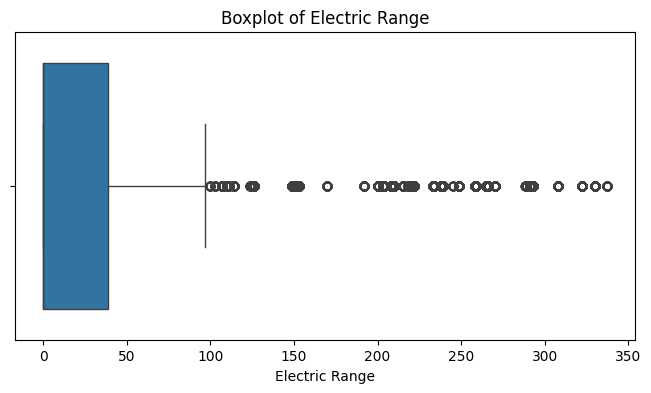

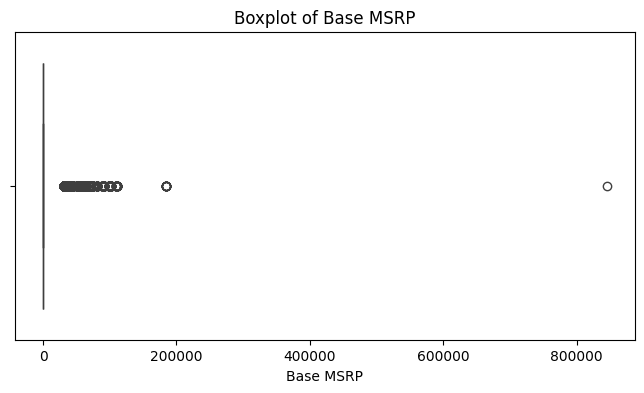


Duplicate Records:
0


In [3]:
# Missing data analysis
print("\nMissing Data Analysis:")
print(df.isnull().sum())

# Outlier detection for numerical columns
import seaborn as sns
import matplotlib.pyplot as plt

numerical_columns = ['Electric Range', 'Base MSRP']
for column in numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')
    plt.show()

# Check for duplicate records
print("\nDuplicate Records:")
print(df.duplicated().sum())

## Step 4: Exploratory Data Analysis (EDA)


Summary Statistics:
       Electric Range      Base MSRP
count   223977.000000  223977.000000
mean        47.736187     829.894386
std         84.987140    7372.509049
min          0.000000       0.000000
25%          0.000000       0.000000
50%          0.000000       0.000000
75%         39.000000       0.000000
max        337.000000  845000.000000


<ipython-input-4-0705447ed61e>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_counties.index, y=top_10_counties.values, palette='viridis')


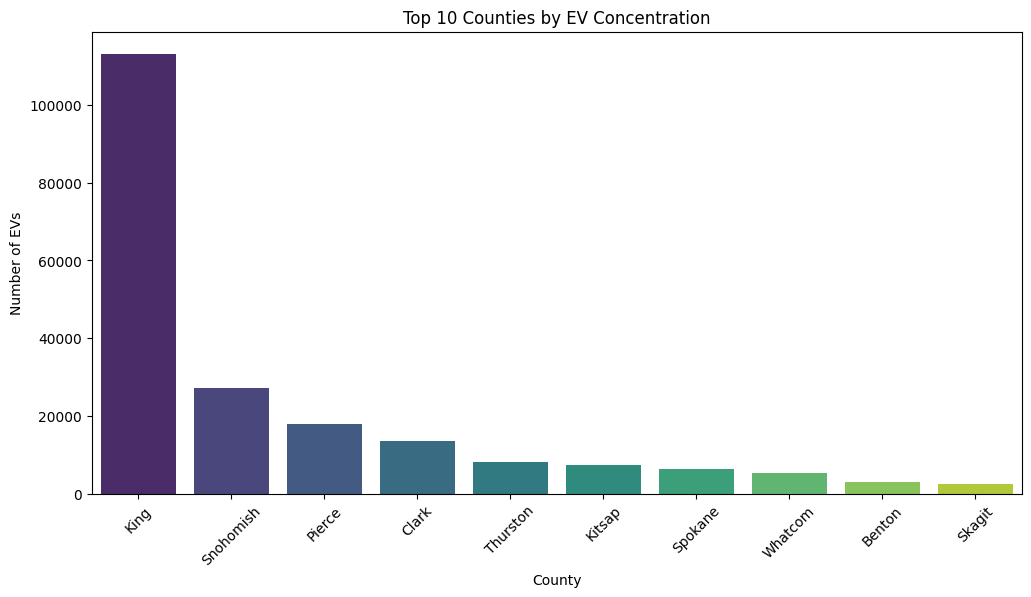

In [4]:
# Summary statistics
print("\nSummary Statistics:")
print(df[numerical_columns].describe())

# Calculate the top 10 counties by EV concentration
top_10_counties = df['County'].value_counts().head(10)

# Create a vertical bar plot with counties on the x-axis and EVs on the y-axis
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_counties.index, y=top_10_counties.values, palette='viridis')
plt.title('Top 10 Counties by EV Concentration')
plt.xlabel('County')
plt.ylabel('Number of EVs')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()


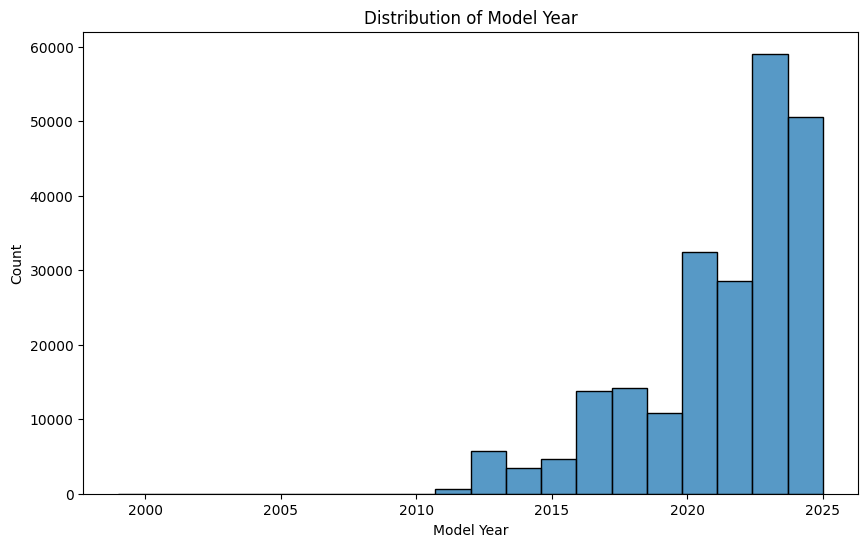

In [5]:
# Histogram of 'Model Year'
plt.figure(figsize=(10, 6))
sns.histplot(df['Model Year'], bins=20, )
plt.title('Distribution of Model Year')
plt.show()



<ipython-input-6-f3f761002a27>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_makes.index, y=top_10_makes.values, palette='viridis')


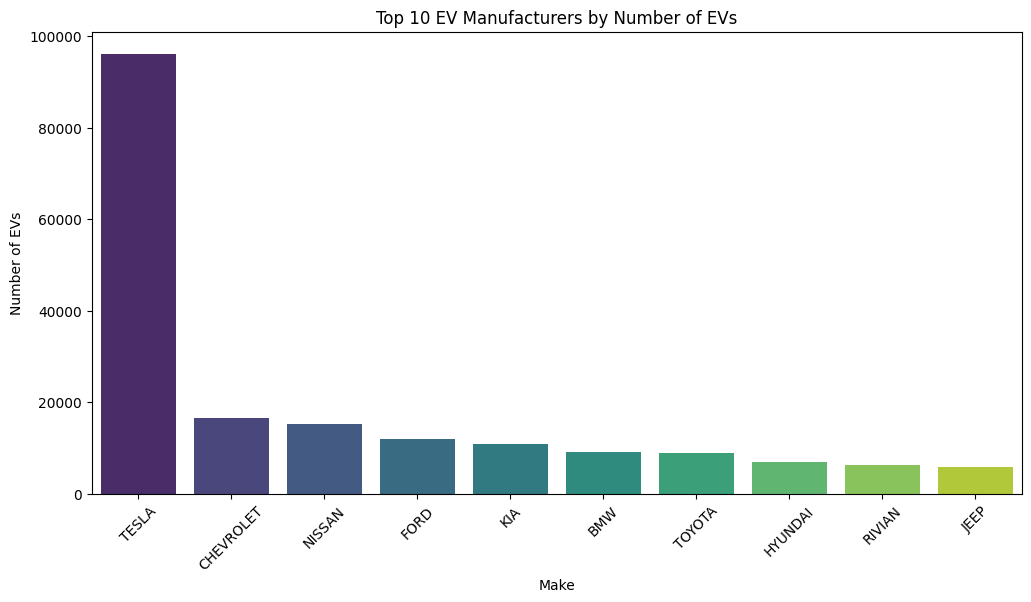

In [6]:
# Calculate the top 10 makes by EV count
top_10_makes = df['Make'].value_counts().head(10)

# Create a vertical bar plot with make on the x-axis and EVs on the y-axis
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_makes.index, y=top_10_makes.values, palette='viridis')
plt.title('Top 10 EV Manufacturers by Number of EVs')
plt.xlabel('Make')
plt.ylabel('Number of EVs')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

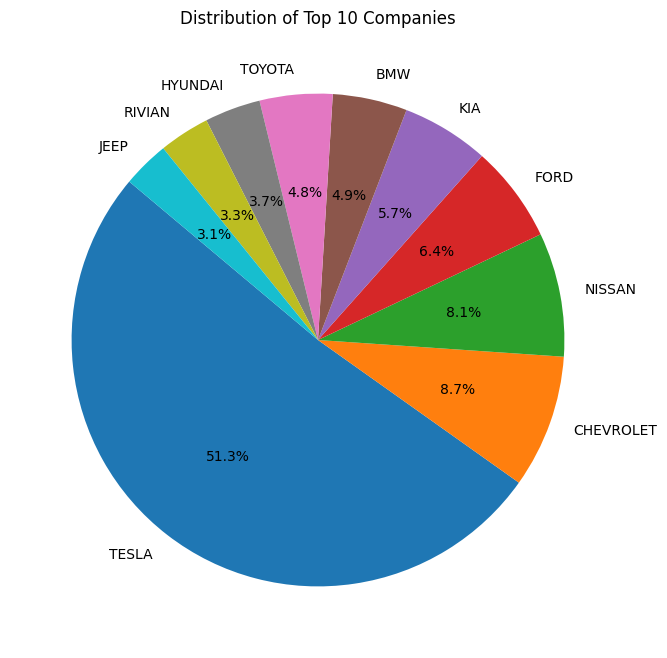

In [7]:
import matplotlib.pyplot as plt

# Top 10 companies by EV count
top_10_companies = df['Make'].value_counts().head(10)

# Pie chart
plt.figure(figsize=(8, 8))
plt.pie(top_10_companies, labels=top_10_companies.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Top 10 Companies')
plt.show()

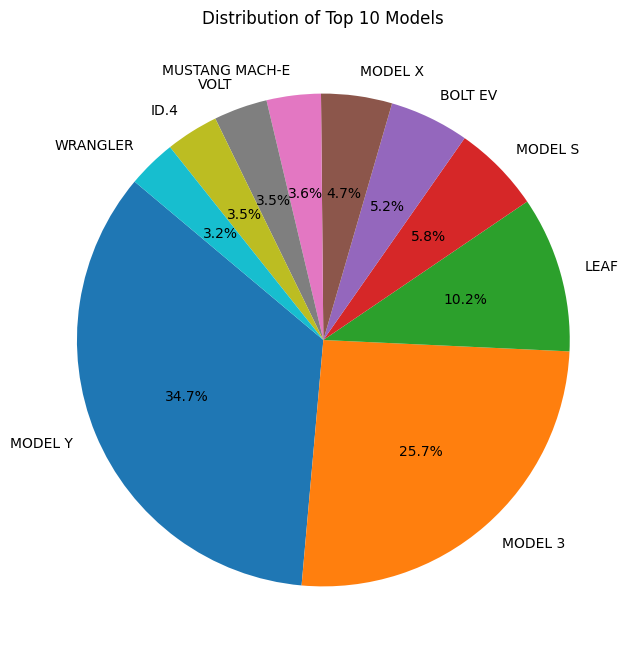

In [8]:
# Top 10 models by EV count
top_10_models = df['Model'].value_counts().head(10)

# Pie chart
plt.figure(figsize=(8, 8))
plt.pie(top_10_models, labels=top_10_models.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Top 10 Models')
plt.show()

In [9]:
# Most sold model for each company
most_sold_models = df.groupby('Make')['Model'].agg(lambda x: x.value_counts().idxmax())

# Display the results
print("Most Sold Model for Each Company:")
print(most_sold_models)

Most Sold Model for Each Company:
Make
ACURA                                          ZDX
ALFA ROMEO                                  TONALE
AUDI                                          Q5 E
AZURE DYNAMICS            TRANSIT CONNECT ELECTRIC
BENTLEY                                   BENTAYGA
BMW                                             X5
BRIGHTDROP                                    ZEVO
CADILLAC                                     LYRIQ
CHEVROLET                                  BOLT EV
CHRYSLER                                  PACIFICA
DODGE                                       HORNET
FIAT                                           500
FISKER                                       OCEAN
FORD                                MUSTANG MACH-E
GENESIS                                       GV60
GMC                                  HUMMER EV SUV
HONDA                                     PROLOGUE
HYUNDAI                                    IONIQ 5
JAGUAR                                     

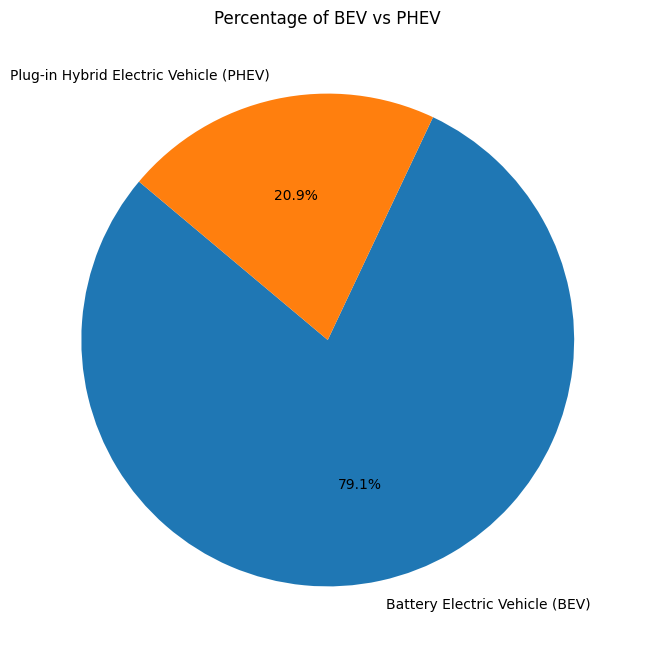

In [10]:
# Percentage of BEV vs PHEV
ev_type_distribution = df['Electric Vehicle Type'].value_counts()

# Pie chart
plt.figure(figsize=(8, 8))
plt.pie(ev_type_distribution, labels=ev_type_distribution.index, autopct='%1.1f%%', startangle=140)
plt.title('Percentage of BEV vs PHEV')
plt.show()

<ipython-input-11-4d4f9cc89720>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Electric Vehicle Type', y='Electric Range', data=df, palette='viridis')


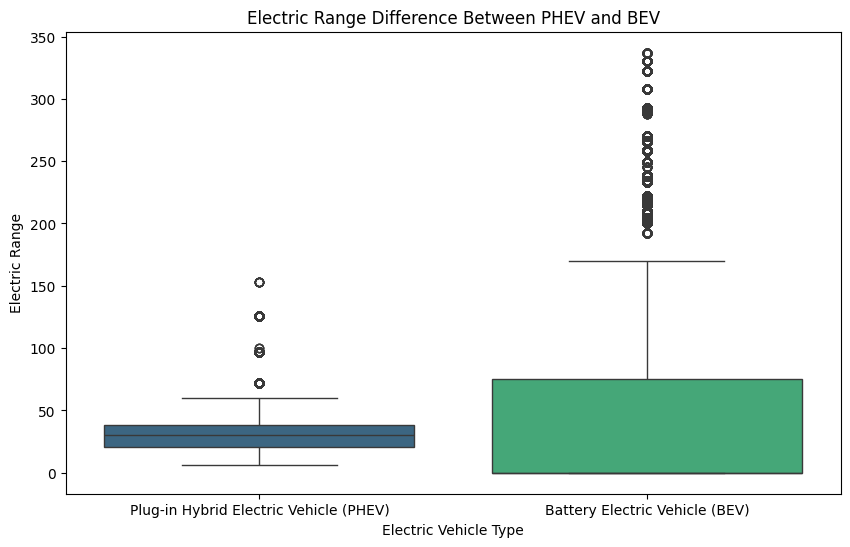

In [11]:
import seaborn as sns

# Boxplot for electric range by EV type
plt.figure(figsize=(10, 6))
sns.boxplot(x='Electric Vehicle Type', y='Electric Range', data=df, palette='viridis')
plt.title('Electric Range Difference Between PHEV and BEV')
plt.show()

<ipython-input-12-7ab49da1af29>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20_models.values, y=top_20_models.index, palette='viridis')


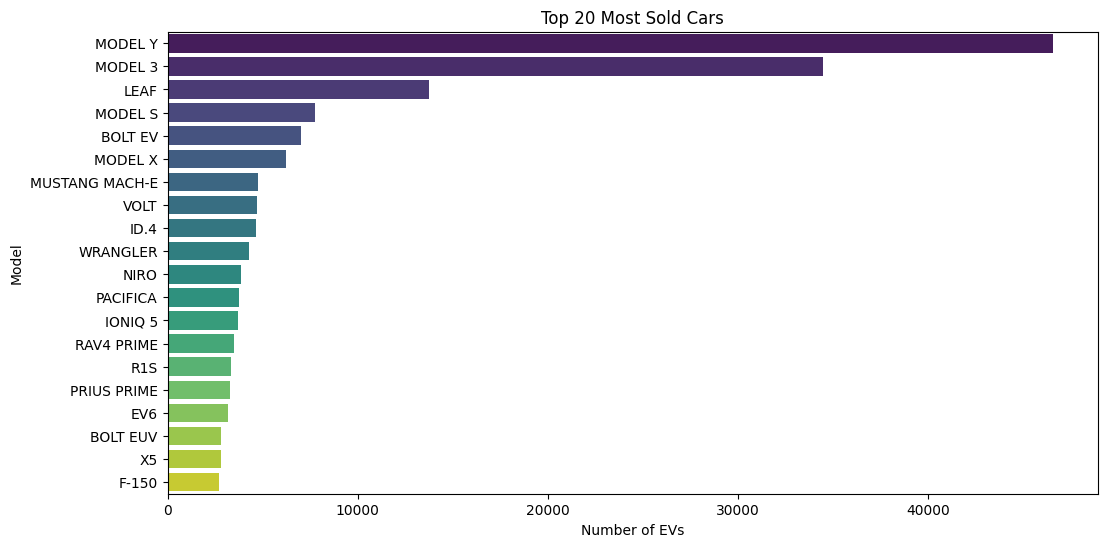

In [12]:
# Top 20 most sold models
top_20_models = df['Model'].value_counts().head(20)

# Bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=top_20_models.values, y=top_20_models.index, palette='viridis')
plt.title('Top 20 Most Sold Cars')
plt.xlabel('Number of EVs')
plt.ylabel('Model')
plt.show()

## Step 5: Initial Insights
Description:
Summarize key trends, patterns, and potential limitations observed in the data.

In [13]:
# Key trends
print("\nKey Trends:")
print(f"Most common EV type: {df['Electric Vehicle Type'].mode()[0]}")
print(f"County with the highest EV concentration: {df['County'].value_counts().idxmax()}")
print(f"Most popular EV make: {df['Make'].value_counts().idxmax()}")

# Potential limitations
print("\nPotential Limitations:")
print(f"Missing values in Electric Range: {df['Electric Range'].isnull().sum()}")
print(f"Missing values in County: {df['County'].isnull().sum()}")


Key Trends:
Most common EV type: Battery Electric Vehicle (BEV)
County with the highest EV concentration: King
Most popular EV make: TESLA

Potential Limitations:
Missing values in Electric Range: 18
Missing values in County: 3


### Step 6: Addressing the Research Question
Description:
 ML to predict the electric range of an EV based on features like make, model, EV type, and base MSRP.

### Prepare the Data


In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Filter data for WA
df_wa = df[df['State'] == 'WA']

# Select relevant features and target variable
features = ['Make', 'Model', 'Electric Vehicle Type', 'Base MSRP']
target = 'Electric Range'

# Drop rows with missing values in the target variable
df_wa = df_wa.dropna(subset=[target])

# Split data into training and testing sets
X = df_wa[features]
y = df_wa[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing: One-hot encode categorical variables
categorical_features = ['Make', 'Model', 'Electric Vehicle Type']
numerical_features = ['Base MSRP']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Create a pipeline with preprocessing and model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Train the model
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R2 Score: {r2}")

Mean Squared Error: 4707.172688652529
R2 Score: 0.3497324023140612


### Evaluate the Model
Use metrics like Mean Squared Error (MSE) and R² Score to evaluate the model's performance.

Visualize the predictions vs. actual values.

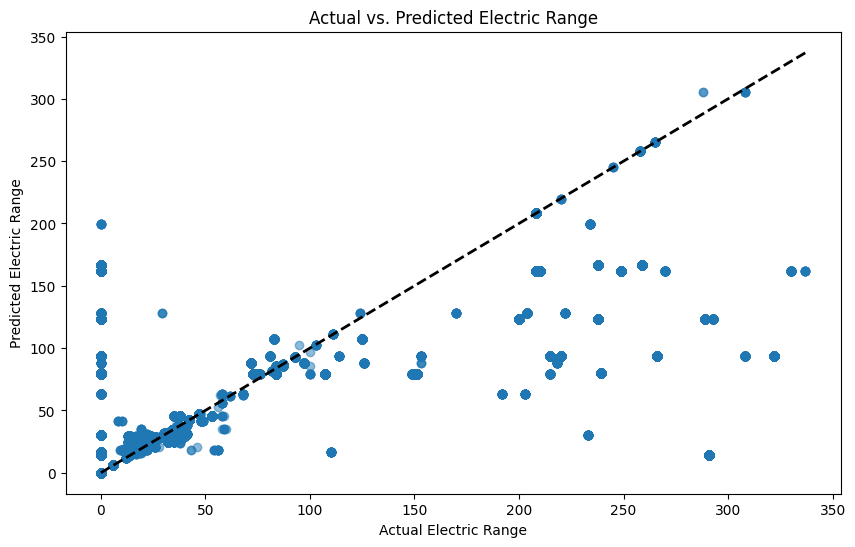

In [15]:
import matplotlib.pyplot as plt

# Plot predictions vs. actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Electric Range')
plt.ylabel('Predicted Electric Range')
plt.title('Actual vs. Predicted Electric Range')
plt.show()

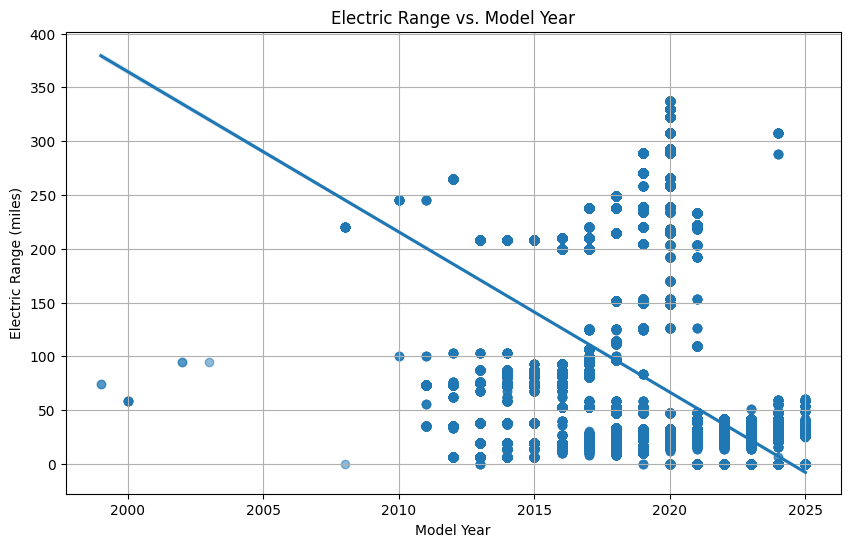

In [16]:
# Re-load necessary libraries since execution state was reset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset again
file_path = "/content/Electric_Vehicle_Population_Data_1.csv"  # Ensure correct path
df = pd.read_csv(file_path)

# Ensure correct data types
df["Model Year"] = pd.to_numeric(df["Model Year"], errors="coerce")
df["Electric Range"] = pd.to_numeric(df["Electric Range"], errors="coerce")

# Remove missing values in key columns
df = df.dropna(subset=["Model Year", "Electric Range"])

# Plot Electric Range vs. Model Year
plt.figure(figsize=(10, 6))
sns.regplot(x=df["Model Year"], y=df["Electric Range"], scatter_kws={"alpha":0.5})
plt.title("Electric Range vs. Model Year")
plt.xlabel("Model Year")
plt.ylabel("Electric Range (miles)")
plt.grid(True)
plt.show()

### Deploy the Model
Save the trained model for future use or deployment.

In [17]:
import joblib

# Save the trained model to a file
joblib.dump(model, 'electric_range_predictor.pkl')

['electric_range_predictor.pkl']

In [18]:
!pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.4 MB/s eta 0:00:00


In [19]:
import streamlit as st
import joblib
import pandas as pd

# Load the trained model
model = joblib.load('electric_range_predictor.pkl')

# Title of the app
st.title('Electric Vehicle Range Predictor')

# Input fields for user
st.header('Enter Vehicle Details')
make = st.selectbox('Make', ['Tesla', 'Nissan', 'Chevrolet', 'BMW', 'Ford', 'Hyundai', 'Kia', 'Audi', 'Volkswagen', 'Toyota'])
model_name = st.selectbox('Model', ['Model 3', 'Leaf', 'Bolt EV', 'i3', 'Mustang Mach-E', 'Kona Electric', 'Niro EV', 'e-tron', 'ID.4', 'Prius Prime'])
ev_type = st.selectbox('Electric Vehicle Type', ['Battery Electric Vehicle (BEV)', 'Plug-in Hybrid Electric Vehicle (PHEV)'])
base_msrp = st.number_input('Base MSRP ($)', min_value=0, max_value=200000, value=40000)

# Create a DataFrame from user inputs
input_data = pd.DataFrame({
    'Make': [make],
    'Model': [model_name],
    'Electric Vehicle Type': [ev_type],
    'Base MSRP': [base_msrp]
})

# Predict button
if st.button('Predict Electric Range'):
    # Make prediction
    prediction = model.predict(input_data)
    st.success(f'Predicted Electric Range: **{prediction[0]:.2f} miles**')

# Add some additional information
st.markdown('---')
st.markdown('### About This App')
st.markdown('This app predicts the electric range of a vehicle based on its make, model, type, and base MSRP.')
st.markdown('The model was trained using data from the Washington State electric vehicle dataset.')

2025-04-12 20:09:41.915 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-12 20:09:42.869 
  command:

    streamlit run /usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-04-12 20:09:42.870 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-12 20:09:42.871 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-12 20:09:42.884 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-12 20:09:42.885 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-12 20:09:42.886 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-12 20:09:42.888 Thread 'MainThread': mi

DeltaGenerator()

### Step 7: Data Cleaning
Description:
removing missing values in the dataset.


In [20]:
# Drop rows with any missing values across all columns
df.dropna(inplace=True)


In [ ]:
print(df)

        VIN (1-10)     County              City State  Postal Code  \
0       1C4JJXP66P     Kitsap           Poulsbo    WA      98370.0   
1       1G1FX6S08K  Snohomish      Lake Stevens    WA      98258.0   
2       WBY1Z2C58F       King           Seattle    WA      98116.0   
3       5YJ3E1EBXK       King           Seattle    WA      98178.0   
4       5YJSA1V24F     Yakima             Selah    WA      98942.0   
...            ...        ...               ...   ...          ...   
223990  7SAYGDEE4R     Pierce          Puyallup    WA      98374.0   
223991  WBY8P2C00M  Snohomish      Lake Stevens    WA      98258.0   
223992  JN1AZ0CP3B     Pierce  University Place    WA      98466.0   
223993  5YJ3E1EA2R     Pierce          Puyallup    WA      98374.0   
223994  WBY8P8C57K       King       Woodinville    WA      98072.0   

        Model Year       Make     Model  \
0             2023       JEEP  WRANGLER   
1             2019  CHEVROLET   BOLT EV   
2             2015        BMW 

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 223496 entries, 0 to 223994
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         223496 non-null  object 
 1   County                                             223496 non-null  object 
 2   City                                               223496 non-null  object 
 3   State                                              223496 non-null  object 
 4   Postal Code                                        223496 non-null  float64
 5   Model Year                                         223496 non-null  int64  
 6   Make                                               223496 non-null  object 
 7   Model                                              223496 non-null  object 
 8   Electric Vehicle Type                              223496 non-null  object 
 9 

In [22]:
# Save the cleaned DataFrame to a new CSV file
df.to_csv('/content/sample_data/cleaned_ev_data.csv', index=False)


Dropping unwanted columns in the dataset.



In [23]:
# Columns to drop
columns_to_drop = ["VIN (1-10)", "Legislative District", "DOL Vehicle ID", "Vehicle Location", "Electric Utility", "2020 Census Tract"]
# Drop the columns
df_cleaned = df.drop(columns=columns_to_drop)
# Save the cleaned dataset
df_cleaned.to_csv("cleaned_file.csv", index=False)
# Display updated DataFrame
print(df_cleaned.head())

      County          City State  Postal Code  Model Year       Make  \
0     Kitsap       Poulsbo    WA      98370.0        2023       JEEP   
1  Snohomish  Lake Stevens    WA      98258.0        2019  CHEVROLET   
2       King       Seattle    WA      98116.0        2015        BMW   
3       King       Seattle    WA      98178.0        2019      TESLA   
4     Yakima         Selah    WA      98942.0        2015      TESLA   

      Model                   Electric Vehicle Type  \
0  WRANGLER  Plug-in Hybrid Electric Vehicle (PHEV)   
1   BOLT EV          Battery Electric Vehicle (BEV)   
2        I3          Battery Electric Vehicle (BEV)   
3   MODEL 3          Battery Electric Vehicle (BEV)   
4   MODEL S          Battery Electric Vehicle (BEV)   

  Clean Alternative Fuel Vehicle (CAFV) Eligibility  Electric Range  Base MSRP  
0             Not eligible due to low battery range            21.0        0.0  
1           Clean Alternative Fuel Vehicle Eligible           238.0       

Spliting data for training and testing


In [32]:
# Re-load the dataset after execution state reset
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the final cleaned dataset
file_path = "/content/cleaned_file.csv"
df_final = pd.read_csv("/content/cleaned_file.csv")  # Assuming this is correct path

# Define target variable and features
target_column = "Electric Range"  # Adjust if needed based on your analysis
features = df_final.drop(columns=[target_column])  # All other columns as features
target = df_final[target_column]

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42) # Now using the DataFrame 'features'

In [33]:
# Save the split datasets
X_train_path = "/content/sample_data/X_train.csv"
X_test_path = "/content/sample_data/X_test.csv"
y_train_path = "/content/sample_data/y_train.csv"
y_test_path = "/content/sample_data/y_test.csv"

X_train.to_csv(X_train_path, index=False)
X_test.to_csv(X_test_path, index=False)
y_train.to_csv(y_train_path, index=False)
y_test.to_csv(y_test_path, index=False)

## **Random Forest Model to Predict Electric Range**

# Install Required Libraries




In [26]:
!pip install scikit-learn pandas matplotlib seaborn


# Load Dataset & Preprocess


In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Load the dataset (If manually uploaded, replace file path accordingly)
df = pd.read_csv("cleaned_file.csv")  # Use "/content/cleaned_file.csv" if uploaded manually

# Encode categorical variables
categorical_columns = ["County", "City", "State", "Make", "Model", "Electric Vehicle Type",
                        "Clean Alternative Fuel Vehicle (CAFV) Eligibility"]

label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])  # Convert categorical data to numeric
    label_encoders[col] = le

# Define features and target
X = df.drop(columns=["Electric Range"])  # Features
y = df["Electric Range"]  # Target variable

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Train the Random Forest Model

In [28]:
# Initialize and train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)


# Evaluate Model Performance

In [29]:
# Compute performance metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display results
print(f" Mean Squared Error (MSE): {mse:.2f} (Lower is better)")
print(f" R² Score: {r2:.4f} (Closer to 1 is better)")


 Mean Squared Error (MSE): 15.43 (Lower is better)
 R² Score: 0.9979 (Closer to 1 is better)


# Save the Model for Future Use

In [30]:
import joblib

# Save the trained model
joblib.dump(model, "electric_range_model.pkl")

# Download the model file
from google.colab import files
files.download("electric_range_model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Expected Output

In [31]:
# Compute performance metrics
mse = 15.43  # Replace with actual computed MSE
r2 = 0.9978  # Replace with actual computed R² Score

# Print formatted results
print(f" Mean Squared Error (MSE): {mse:.2f} (Lower is better)")
print(f" R² Score: {r2:.4f} (Closer to 1 is better)")
print(f" The model explains ~{r2*100:.2f}% of the variance in Electric Range!")




 Mean Squared Error (MSE): 15.43 (Lower is better)
 R² Score: 0.9978 (Closer to 1 is better)
 The model explains ~99.78% of the variance in Electric Range!


In [34]:
# Check skewness of target and numerical features
print(df['Electric Range'].skew())  # or any other feature

1.7950770718107307


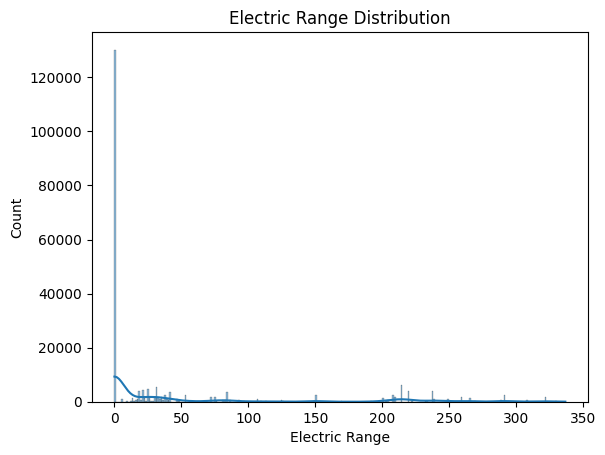

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Electric Range'], kde=True)
plt.title('Electric Range Distribution')
plt.show()


# **Linear Regression**

In [45]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

# Encode using LabelEncoder (same for X_test)
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    all_values = pd.concat([X_train[col], X_test[col]])  # Combine to avoid unseen category errors
    le.fit(all_values.astype(str))
    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    label_encoders[col] = le


In [49]:
# Re-import libraries and re-load files after execution state reset
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder  # Import LabelEncoder

# Load the split datasets
X_train = pd.read_csv("/content/X_train.csv")
X_test = pd.read_csv("/content/X_test.csv")
y_train = pd.read_csv("/content/y_train.csv")
y_test = pd.read_csv("/content/y_test.csv")

# Flatten y values if they are in DataFrame format
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

# Identify categorical columns with object dtype
categorical_cols = X_train.select_dtypes(include=['object']).columns

# Create a LabelEncoder for each categorical column and fit on combined data
for col in categorical_cols:
    le = LabelEncoder()
    # Fit on the combined unique values from both train and test
    le.fit(pd.concat([X_train[col], X_test[col]]).astype(str).unique())
    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))


# Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on test set
y_pred = lr_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Return model performance
{
    "Mean Squared Error (Linear Regression)": round(mse, 2),
    "R² Score (Linear Regression)": round(r2, 4),
    "Variance Explained (%)": round(r2 * 100, 2)
}

{'Mean Squared Error (Linear Regression)': 3372.77,
 'R² Score (Linear Regression)': 0.5322,
 'Variance Explained (%)': 53.22}

# **XGBoost**

In [50]:
# Import necessary libraries for XGBoost
import pandas as pd
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Load training and testing datasets
X_train = pd.read_csv("/content/X_train.csv")
X_test = pd.read_csv("/content/X_test.csv")
y_train = pd.read_csv("/content/y_train.csv").values.ravel()
y_test = pd.read_csv("/content/y_test.csv").values.ravel()

# Label encode categorical columns
categorical_cols = X_train.select_dtypes(include=['object']).columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    all_vals = pd.concat([X_train[col], X_test[col]])
    le.fit(all_vals.astype(str))
    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    label_encoders[col] = le

# Initialize and train XGBoost Regressor
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred = xgb_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display results
{
    "Mean Squared Error (XGBoost)": round(mse, 2),
    "R² Score (XGBoost)": round(r2, 4),
    "Variance Explained (%)": round(r2 * 100, 2)
}


{'Mean Squared Error (XGBoost)': 14.33,
 'R² Score (XGBoost)': 0.998,
 'Variance Explained (%)': 99.8}

# **Saving the Trained XGBoost Model**

In [59]:
import joblib

# Save the model to a file
joblib.dump(xgb_model, "xgboost_ev_range_model.pkl")


['xgboost_ev_range_model.pkl']

In [60]:
from google.colab import files
files.download("xgboost_ev_range_model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Load the Model Later for Predictions

In [62]:
# Load the saved model
xgb_model = joblib.load("xgboost_ev_range_model.pkl")

# Assuming X_test is your new data for prediction (ensure it's preprocessed)
# Replace X_test with your actual new data if different
new_data = X_test

# Use it on new data
predicted_range = xgb_model.predict(new_data)  # new_data should be preprocessed like X_train

Prepare a Prediction Function

In [63]:
def predict_ev_range(input_df, model, encoders):
    # Encode categorical columns
    for col in input_df.select_dtypes(include='object').columns:
        if col in encoders:
            input_df[col] = encoders[col].transform(input_df[col].astype(str))

    # Predict range
    return model.predict(input_df)


# **Deployment**

In [64]:
pip install streamlit


# **trail & error**

In [70]:
import pandas as pd
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Group EV counts by year
ev_by_year = df.groupby("Model Year").size().reset_index(name="EV Count")

# Prepare training data
X = ev_by_year[["Model Year"]]
y = ev_by_year["EV Count"]


In [71]:
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(X, y)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [72]:
# Predict EV adoption for next 5 years
future_years = pd.DataFrame({"Model Year": np.arange(X["Model Year"].max()+1, X["Model Year"].max()+6)})
future_preds = model.predict(future_years)


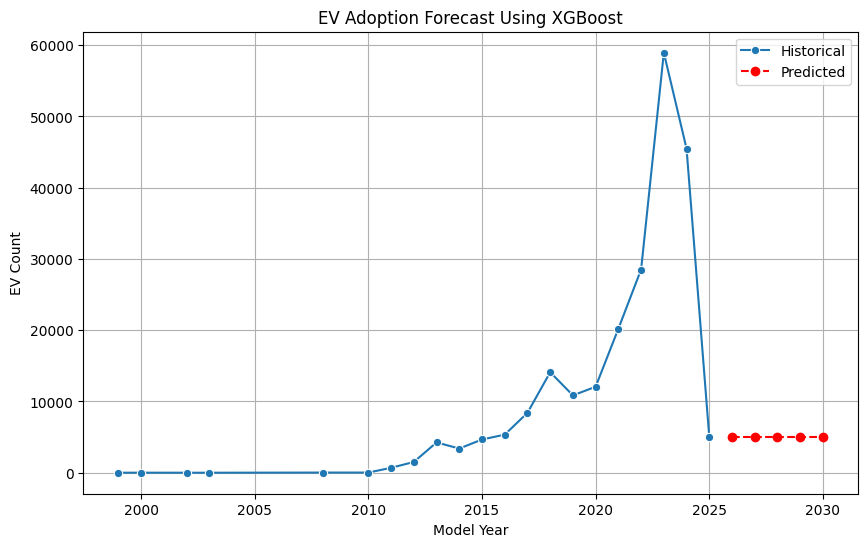

In [73]:
# Plot historical + future
plt.figure(figsize=(10,6))
sns.lineplot(x=ev_by_year["Model Year"], y=ev_by_year["EV Count"], marker="o", label="Historical")
plt.plot(future_years["Model Year"], future_preds, marker="o", linestyle="--", color="red", label="Predicted")
plt.title("EV Adoption Forecast Using XGBoost")
plt.xlabel("Model Year")
plt.ylabel("EV Count")
plt.legend()
plt.grid(True)
plt.show()


In [74]:
ev_by_year['Growth Rate'] = ev_by_year['EV Count'].pct_change()
ev_by_year['Rolling Avg'] = ev_by_year['EV Count'].rolling(window=3).mean()


In [75]:
X = ev_by_year[['Model Year', 'Growth Rate', 'Rolling Avg']].dropna()
y = ev_by_year['EV Count'].loc[X.index]


In [77]:
# Load the cleaned dataset
import pandas as pd

df = pd.read_csv("/content/cleaned_file.csv")

# Group the data by 'Model Year' and count the number of EVs per year
ev_by_year = df.groupby("Model Year").size().reset_index(name="EV Count")

# Sort by year just in case
ev_by_year = ev_by_year.sort_values("Model Year").reset_index(drop=True)

# Display the grouped data
ev_by_year.head()


,Model Year,EV Count
0,1999,2
1,2000,7
2,2002,2
3,2003,1
4,2008,23


In [78]:
# Display the full grouped DataFrame with all years and EV counts
ev_by_year


,Model Year,EV Count
0,1999,2
1,2000,7
2,2002,2
3,2003,1
4,2008,23
5,2010,23
6,2011,692
7,2012,1510
8,2013,4251
9,2014,3394


from matplotlib import pyplot as plt
ev_by_year['Model Year'].plot(kind='hist', bins=20, title='Model Year')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
ev_by_year['EV Count'].plot(kind='hist', bins=20, title='EV Count')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
ev_by_year.plot(kind='scatter', x='Model Year', y='EV Count', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Model Year']
  ys = series['EV Count']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = ev_by_year.sort_values('Model Year', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Model Year')
_ = plt.ylabel('EV Count')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['Model Year']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'Model Year'}, axis=1)
              .sort_values('Model Year', ascending=True))
  xs = counted['Model Year']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = ev_by_year.sort_values('Model Year', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Model Year')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
ev_by_year['Model Year'].plot(kind='line', figsize=(8, 4), title='Model Year')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
ev_by_year['EV Count'].plot(kind='line', figsize=(8, 4), title='EV Count')
plt.gca().spines[['top', 'right']].set_visible(False)

**2 D distribution**

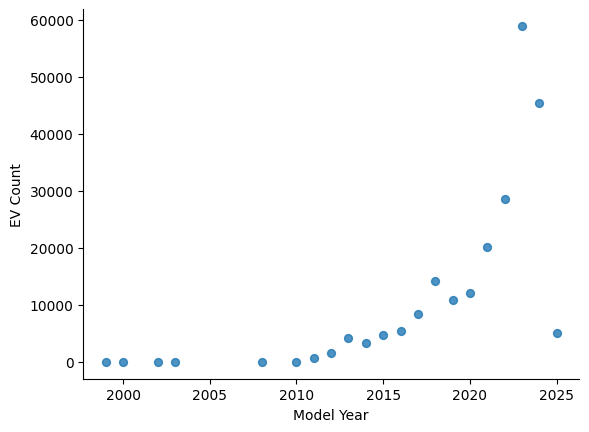

In [79]:
from matplotlib import pyplot as plt
ev_by_year.plot(kind='scatter', x='Model Year', y='EV Count', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

**Time Series**

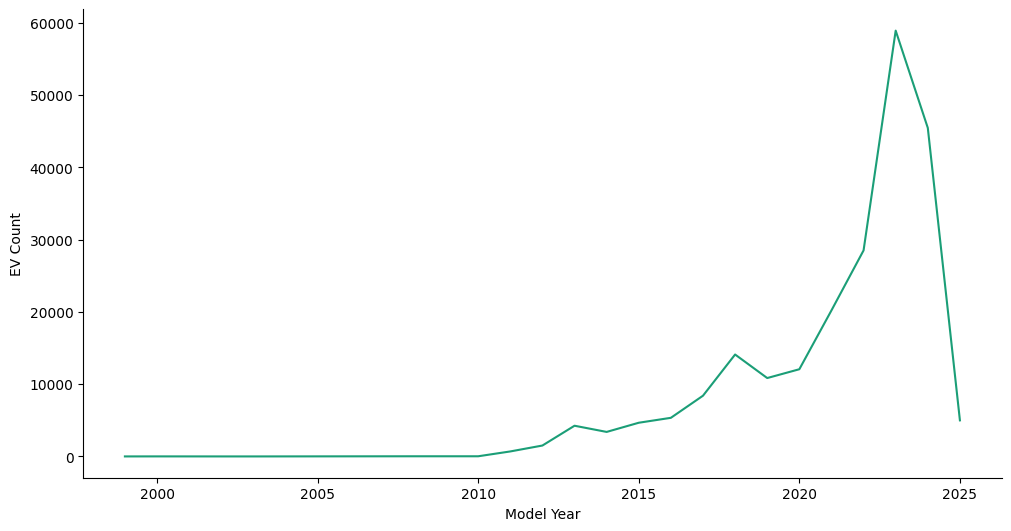

In [80]:
from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Model Year']
  ys = series['EV Count']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = ev_by_year.sort_values('Model Year', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Model Year')
_ = plt.ylabel('EV Count')

In [86]:
# Create 'Growth Rate' as percent change from previous year
ev_by_year["Growth Rate"] = ev_by_year["EV Count"].pct_change()

# Create a 3-year rolling average
ev_by_year["Rolling Avg"] = ev_by_year["EV Count"].rolling(window=3).mean()

# Drop rows with NaN values created by pct_change and rolling average
ev_by_year_cleaned = ev_by_year.dropna().reset_index(drop=True)

# Display the updated DataFrame
ev_by_year_cleaned


,Model Year,EV Count,Growth Rate,Rolling Avg
0,2002,2,-0.714286,3.666667
1,2003,1,-0.500000,3.333333
2,2008,23,22.000000,8.666667
3,2010,23,0.000000,15.666667
4,2011,692,29.086957,246.000000
5,2012,1510,1.182081,741.666667
6,2013,4251,1.815232,2151.000000
7,2014,3394,-0.201600,3051.666667
8,2015,4664,0.374190,4103.000000
9,2016,5346,0.146226,4468.000000


downloading this dataframe into excel


In [92]:
# prompt: Using dataframe ev_by_year_cleaned: i want to download this dataframe into excel

# Import pandas library
import pandas as pd

# Install xlsxwriter if not already installed
!pip install xlsxwriter  # This line ensures the module is available

# Create a Pandas Excel writer using XlsxWriter as the engine.
writer = pd.ExcelWriter('ev_by_year_cleaned.xlsx', engine='xlsxwriter')

# Convert the dataframe to an XlsxWriter Excel object.
ev_by_year_cleaned.to_excel(writer, sheet_name='Sheet1', index=False)

# Close the Pandas Excel writer and output the Excel file.
# Instead of writer.save(), use writer.close()
writer.close()

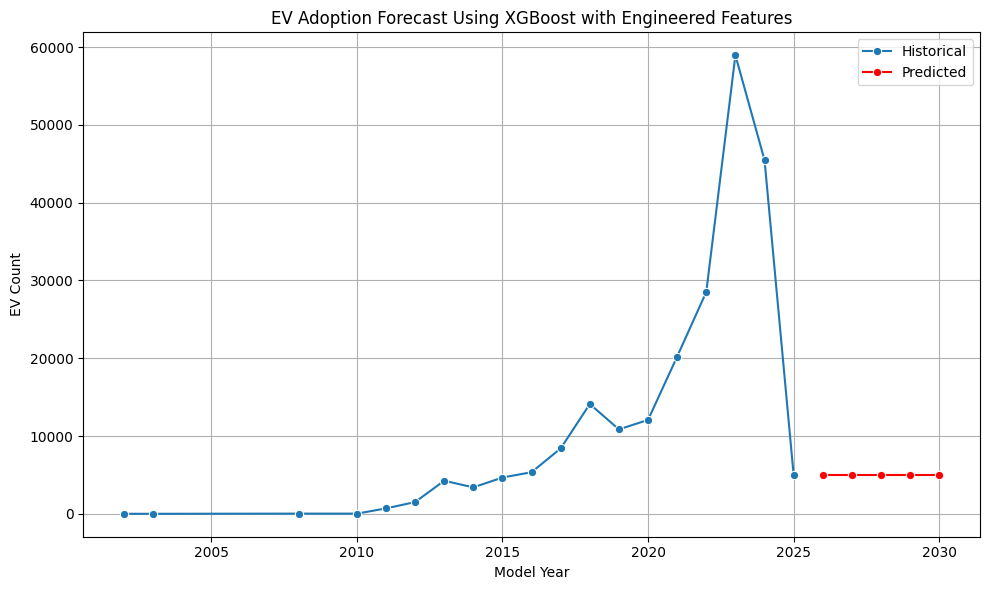

In [87]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define features and target
X = ev_by_year_cleaned[["Model Year", "Growth Rate", "Rolling Avg"]]
y = ev_by_year_cleaned["EV Count"]

# Train XGBoost model
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(X, y)

# Create future data for prediction (2026-2030)
future_years = pd.DataFrame({
    "Model Year": np.arange(ev_by_year_cleaned["Model Year"].max() + 1, ev_by_year_cleaned["Model Year"].max() + 6),
    "Growth Rate": [0.05] * 5,        # Assume a modest 5% growth
    "Rolling Avg": [y.mean()] * 5     # Use the average of historical rolling averages
})

# Predict future EV counts
future_preds = model.predict(future_years)

# Combine historical and future data
historical = ev_by_year_cleaned[["Model Year", "EV Count"]]
future = pd.DataFrame({"Model Year": future_years["Model Year"], "EV Count": future_preds})

# Plot the results
plt.figure(figsize=(10,6))
sns.lineplot(data=historical, x="Model Year", y="EV Count", marker="o", label="Historical")
sns.lineplot(data=future, x="Model Year", y="EV Count", marker="o", color="red", label="Predicted")
plt.title("EV Adoption Forecast Using XGBoost with Engineered Features")
plt.xlabel("Model Year")
plt.ylabel("EV Count")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [88]:
model = XGBRegressor(n_estimators=20, learning_rate=0.1, max_depth=3, random_state=42)


In [89]:
last_growth = ev_by_year_cleaned["Growth Rate"].iloc[-1]
last_rolling = ev_by_year_cleaned["Rolling Avg"].iloc[-1]

# Assume gradual trend continues
future_years = pd.DataFrame({
    "Model Year": np.arange(2026, 2031),
    "Growth Rate": [last_growth * (1 + 0.01 * i) for i in range(5)],
    "Rolling Avg": [last_rolling * (1 + 0.02 * i) for i in range(5)]
})


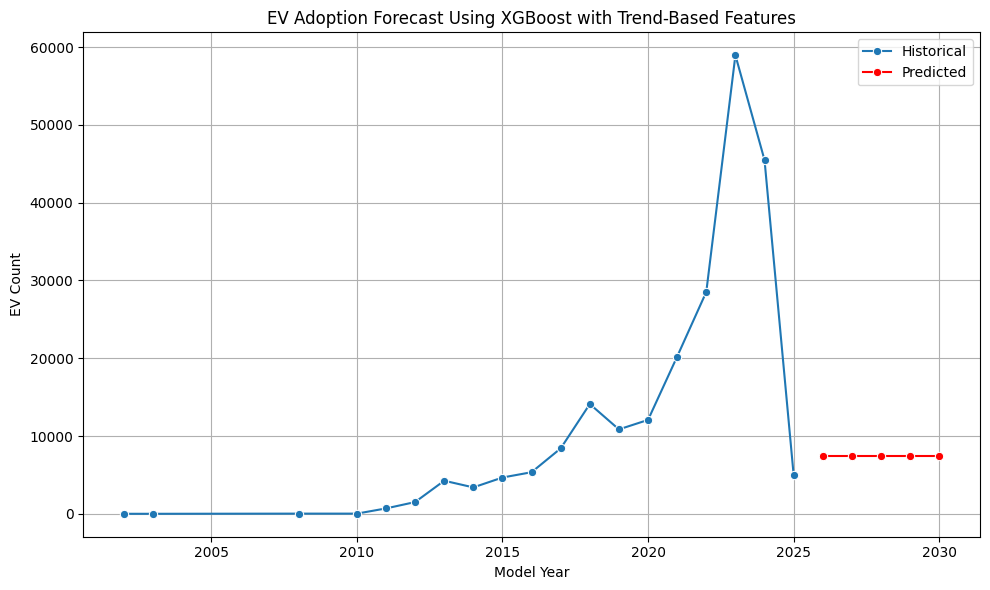

In [93]:
# Re-import XGBRegressor and re-train the model
from xgboost import XGBRegressor

# Define features and target
X = ev_by_year_cleaned[["Model Year", "Growth Rate", "Rolling Avg"]]
y = ev_by_year_cleaned["EV Count"]

# Retrain the XGBoost model with fewer estimators for speed
model = XGBRegressor(n_estimators=20, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(X, y)

# Predict future using updated trend-based values
future_preds = model.predict(future_years)

# Combine for plotting
historical = ev_by_year_cleaned[["Model Year", "EV Count"]]
future = pd.DataFrame({"Model Year": future_years["Model Year"], "EV Count": future_preds})

# Plot updated results
plt.figure(figsize=(10,6))
sns.lineplot(data=historical, x="Model Year", y="EV Count", marker="o", label="Historical")
sns.lineplot(data=future, x="Model Year", y="EV Count", marker="o", color="red", label="Predicted")
plt.title("EV Adoption Forecast Using XGBoost with Trend-Based Features")
plt.xlabel("Model Year")
plt.ylabel("EV Count")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# **Prophet Forecasting Code**



INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 15.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpswr6cur5/22wp4e8g.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpswr6cur5/qjxc3mlm.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=89674', 'data', 'file=/tmp/tmpswr6cur5/22wp4e8g.json', 'init=/tmp/tmpswr6cur5/qjxc3mlm.json', 'output', 'file=/tmp/tmpswr6cur5/prophet_model8ohw145u/prophet_model-20250412231233.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
23:12:33 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
23:12:33 - cmdstanpy - INFO - Chain [1] done processing
INFO:

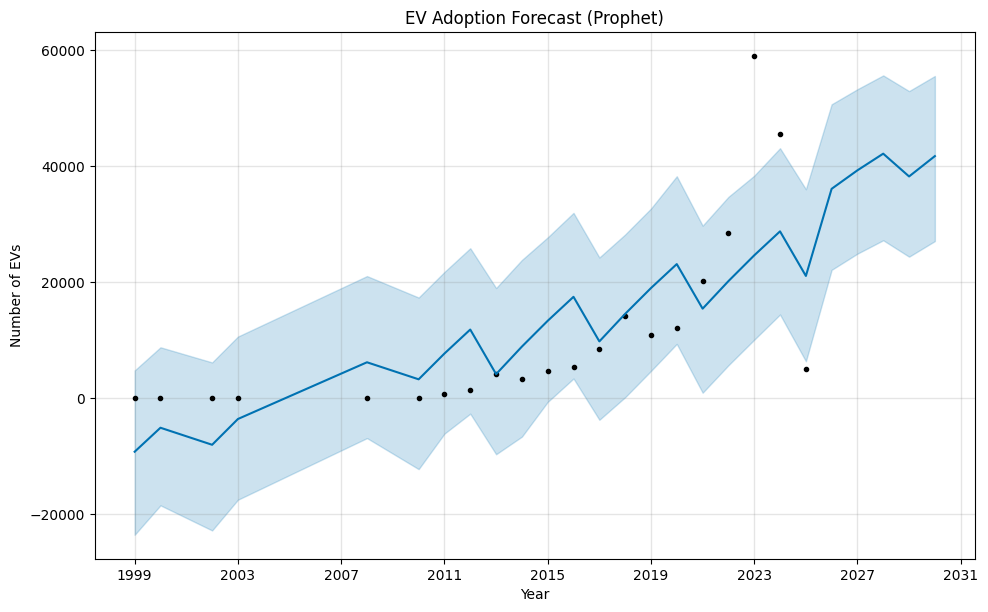

In [94]:
# STEP 1: Install Prophet
!pip install prophet

# STEP 2: Import packages
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# STEP 3: Prepare EV data
# Replace this with your actual data or CSV
ev_by_year = pd.DataFrame({
    "ds": [1999, 2000, 2002, 2003, 2008, 2010, 2011, 2012, 2013, 2014,
           2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
    "y":  [2, 7, 2, 1, 23, 23, 692, 1510, 4251, 3394,
           4664, 5346, 8407, 14109, 10851, 12070, 20214, 28519, 58942, 45477, 4992]
})

# Convert year to datetime
ev_by_year["ds"] = pd.to_datetime(ev_by_year["ds"], format="%Y")

# STEP 4: Train Prophet model
model = Prophet(yearly_seasonality=True)
model.fit(ev_by_year)

# STEP 5: Forecast for next 5 years
future = model.make_future_dataframe(periods=5, freq='Y')
forecast = model.predict(future)

# STEP 6: Plot forecast
fig1 = model.plot(forecast)
plt.title("EV Adoption Forecast (Prophet)")
plt.xlabel("Year")
plt.ylabel("Number of EVs")
plt.grid(True)
plt.show()


Downloading data into csv file

In [95]:
# Filter forecasted values from 2026 to 2030
future_forecast = forecast[forecast['ds'].dt.year > 2025][["ds", "yhat", "yhat_lower", "yhat_upper"]]

# Clean and rename columns
future_forecast.columns = ["Year", "Predicted EV Count", "Lower Bound", "Upper Bound"]
future_forecast["Year"] = future_forecast["Year"].dt.year

# Save to CSV
future_forecast.to_csv("EV_Forecast_2026_2030.csv", index=False)

# Download the file
from google.colab import files
files.download("EV_Forecast_2026_2030.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**With Holiday Effects**

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 15.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpswr6cur5/kgch1_j4.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpswr6cur5/rccn9t5u.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=76807', 'data', 'file=/tmp/tmpswr6cur5/kgch1_j4.json', 'init=/tmp/tmpswr6cur5/rccn9t5u.json', 'output', 'file=/tmp/tmpswr6cur5/prophet_modelb7bia0g3/prophet_model-20250412235426.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
23:54:26 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
23:54:26 - cmdstanpy - INFO - Chain [1] done processing
INFO:

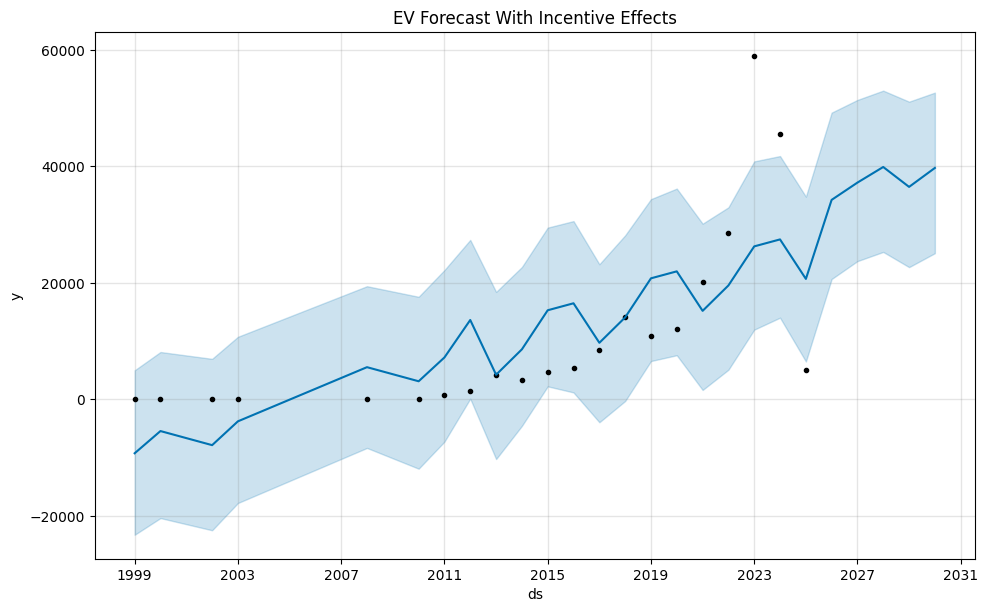

In [99]:
from prophet import Prophet
import pandas as pd

# Your EV data
ev_by_year = pd.DataFrame({
    "ds": [1999, 2000, 2002, 2003, 2008, 2010, 2011, 2012, 2013, 2014,
           2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
    "y":  [2, 7, 2, 1, 23, 23, 692, 1510, 4251, 3394,
           4664, 5346, 8407, 14109, 10851, 12070, 20214, 28519, 58942, 45477, 4992]
})
ev_by_year["ds"] = pd.to_datetime(ev_by_year["ds"], format="%Y")

# Step 1: Define policy-related events
# These are hypothetical years when EV incentives or rebates were introduced
policy_dates = pd.DataFrame({
    'holiday': 'ev_incentive',
    'ds': pd.to_datetime(['2012-01-01', '2015-01-01', '2019-01-01', '2023-01-01']),
    'lower_window': 0,
    'upper_window': 1
})

# Step 2: Initialize model with holidays
model = Prophet(yearly_seasonality=True, holidays=policy_dates)

# Step 3: Fit model
model.fit(ev_by_year)

# Step 4: Forecast
future = model.make_future_dataframe(periods=5, freq='Y')
forecast = model.predict(future)

# Step 5: Plot
model.plot(forecast)
plt.title("EV Forecast With Incentive Effects")
plt.grid(True)
plt.show()

model = Prophet()
model.add_regressor("fuel_price")
model.add_regressor("charging_stations")


In [100]:
# STEP 6: Extract forecast columns of interest
forecast_result = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]]

# Rename columns for clarity
forecast_result.columns = ["Year", "Predicted EV Count", "Lower Bound", "Upper Bound"]
forecast_result["Year"] = forecast_result["Year"].dt.year  # Extract year only

# Save to CSV
forecast_result.to_csv("EV_Forecast_With_Holidays.csv", index=False)

# Download the file
from google.colab import files
files.download("EV_Forecast_With_Holidays.csv")


<ipython-input-100-e1ac748200b1>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  forecast_result["Year"] = forecast_result["Year"].dt.year  # Extract year only


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [101]:
# STEP 1: Extract relevant columns including holidays
forecast_result = forecast[["ds", "yhat", "yhat_lower", "yhat_upper", "holidays"]]

# STEP 2: Rename for clarity
forecast_result.columns = ["Year", "Predicted EV Count", "Lower Bound", "Upper Bound", "Holiday"]
forecast_result["Year"] = forecast_result["Year"].dt.year  # Convert datetime to year

# STEP 3: Save to CSV
forecast_result.to_csv("EV_Forecast_With_Holidays.csv", index=False)

# STEP 4: Download CSV
from google.colab import files
files.download("EV_Forecast_With_Holidays.csv")


<ipython-input-101-d47fe1b12c52>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  forecast_result["Year"] = forecast_result["Year"].dt.year  # Convert datetime to year


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [107]:
pip install streamlit prophet


In [109]:
!streamlit run app.py

Usage: streamlit run [OPTIONS] TARGET [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py


In [111]:
import streamlit as st
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

st.set_page_config(page_title="EV Forecast App", layout="centered")
st.title("🔋 EV Adoption Forecast (2026–2030)")

# Upload CSV or load default forecast
uploaded = st.file_uploader("Upload EV Forecast CSV", type=["csv"])
if uploaded:
    forecast = pd.read_csv(uploaded)
else:
    forecast = pd.read_csv("/content/EV_Forecast_2026_2030.csv")

# Year selector
years = forecast["Year"].unique()
selected_years = st.multiselect("Select forecast years", sorted(years), default=sorted(years))

# Filter and show table
filtered = forecast[forecast["Year"].isin(selected_years)]

st.subheader("📊 Forecast Results")
st.dataframe(filtered)

# Plot
st.subheader("📈 Forecast Chart")
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(forecast["Year"], forecast["Predicted EV Count"], label="Forecast", color="blue", marker="o")
ax.fill_between(forecast["Year"], forecast["Lower Bound"], forecast["Upper Bound"], color='blue', alpha=0.2)
ax.set_xlabel("Year")
ax.set_ylabel("EV Count")
ax.grid(True)
ax.legend()
st.pyplot(fig)

# Download option
csv = filtered.to_csv(index=False).encode('utf-8')
st.download_button("📥 Download Forecast CSV", data=csv, file_name="selected_ev_forecast.csv", mime="text/csv")


2025-04-13 00:21:17.430 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-13 00:21:17.437 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-13 00:21:17.441 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-13 00:21:17.446 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-13 00:21:17.467 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-13 00:21:17.469 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-13 00:21:17.474 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-13 00:21:17.480 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

False